## Machine Learning (Train -> Test)

RQ1: Class Imbalance Sensitivity - How do ML models perform as malicious email ratio decreases in training data?


🚀 Email Phishing Classification: Class Imbalance Sensitivity Analysis
Research Question 1: How do ML models perform as malicious email ratio increases?
Malicious ratios tested: 10%, 20%, 30%, 40%, 50%
Classifiers: SVM, Random Forest, XGBoost
📂 Data Files:
   Training: ../raw/email_phishing_CEAS-08_train.csv.gz
   Testing: ../raw/email_phishing_CEAS-08_test.csv.gz
   Synthetic: ../data/synthetic/email_phishing_CEAS-08_synthetic.csv.gz

🎯 Experimental Setup:
   Malicious ratios: ['10%', '20%', '30%', '40%', '50%']
   Cross-validation: 5-fold
   Random state: 42

📊 LOADING DATASETS

📥 Loading training data from: ../raw/email_phishing_CEAS-08_train.csv.gz
   ✅ Loaded successfully!
   Shape: (1000, 4)
   Columns: ['subject', 'body', 'label', 'source']
   Label distribution:
      Benign (0): 500 (50.0%)
      Malicious (1): 500 (50.0%)

📥 Loading test data from: ../raw/email_phishing_CEAS-08_test.csv.gz
   ✅ Loaded successfully!
   Shape: (1000, 4)
   Columns: ['subject', 'body', 'label', '

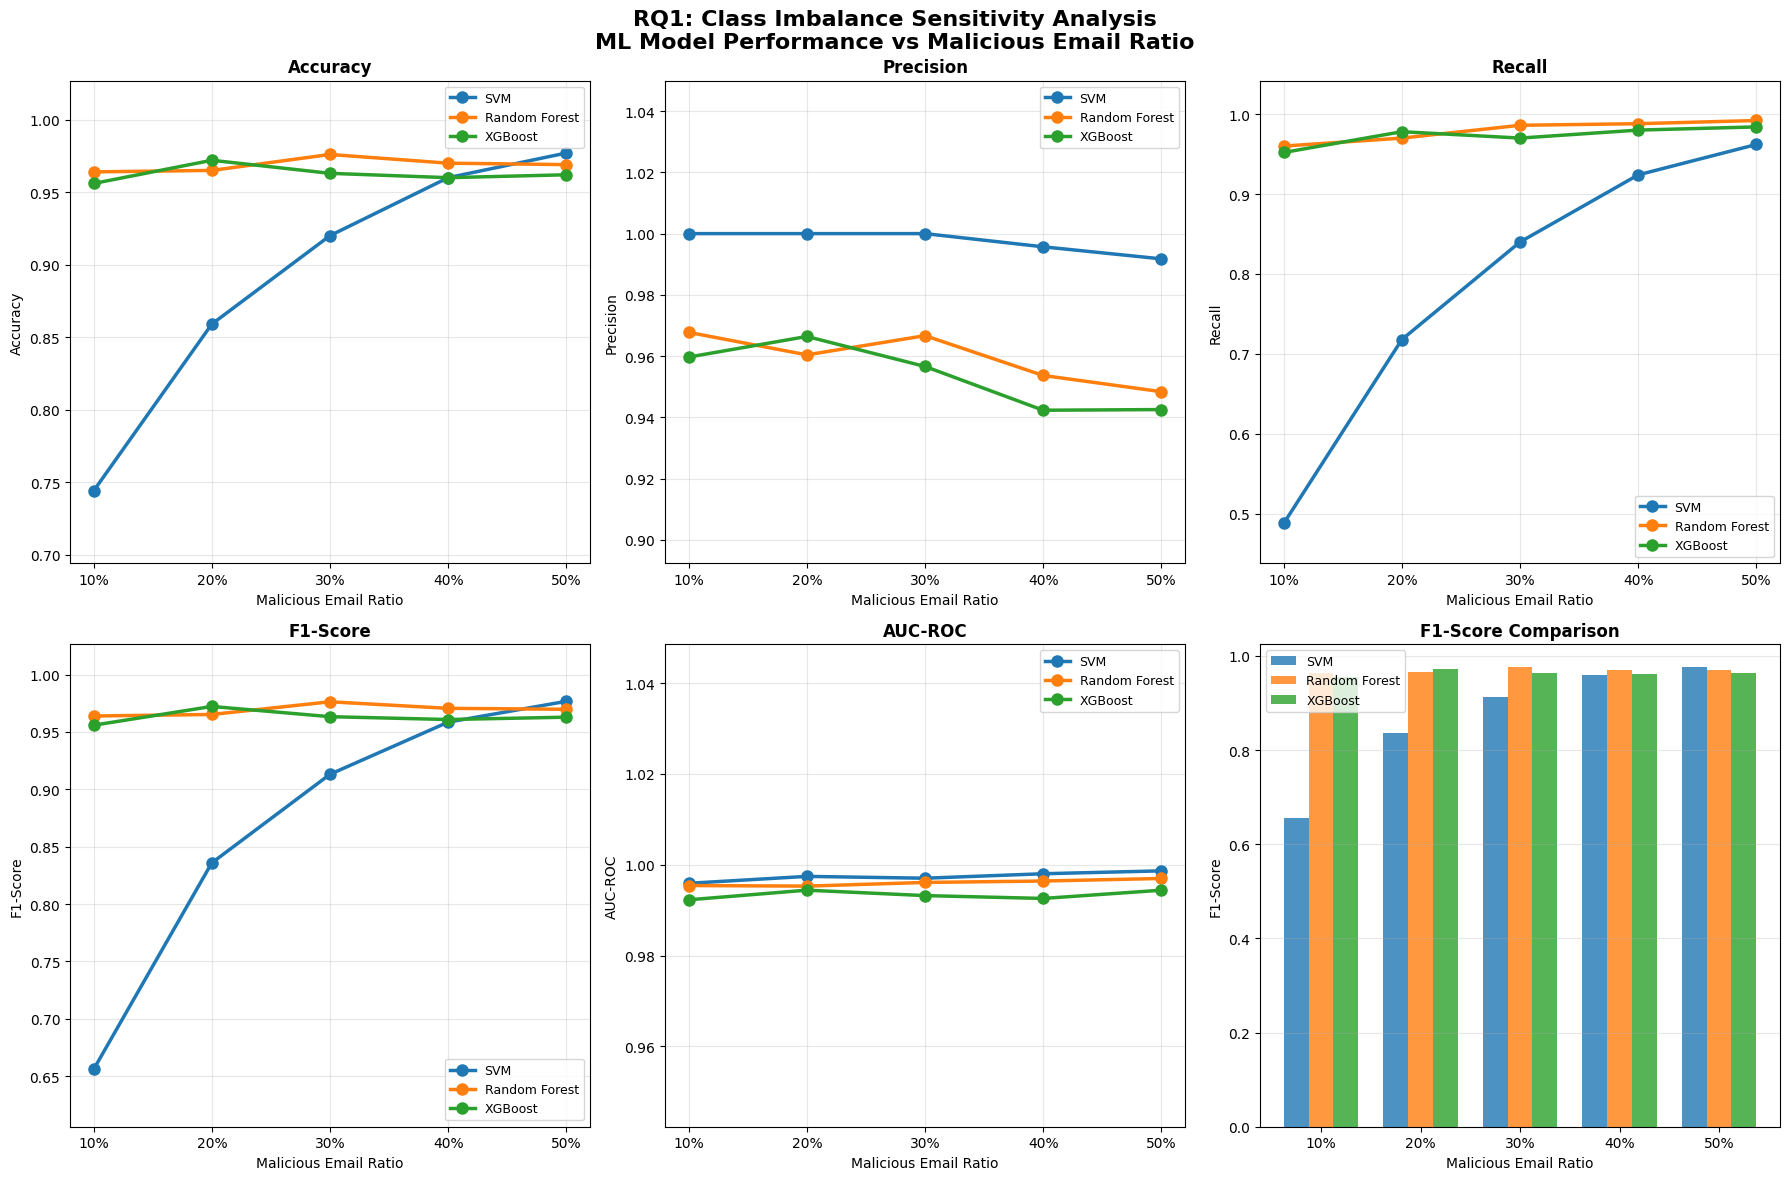

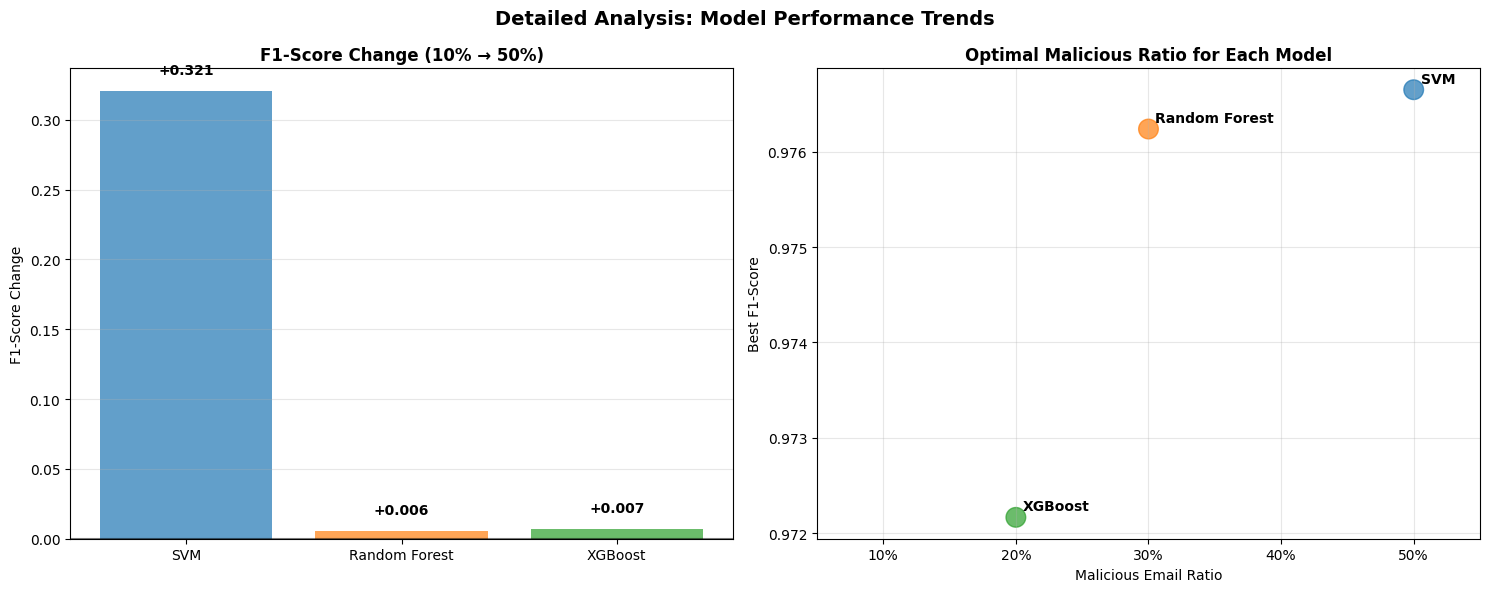


🔍 KEY FINDINGS - RQ1: CLASS IMBALANCE SENSITIVITY

🏆 OVERALL BEST PERFORMING MODEL:
   Model: Random Forest
   Average F1-Score: 0.969

📊 PERFORMANCE BY MALICIOUS RATIO:
   10% Malicious - Best: Random Forest (F1: 0.964)
   20% Malicious - Best: XGBoost (F1: 0.972)
   30% Malicious - Best: Random Forest (F1: 0.976)
   40% Malicious - Best: Random Forest (F1: 0.971)
   50% Malicious - Best: SVM (F1: 0.977)

📉 PERFORMANCE DEGRADATION (10% → 50%):
   SVM: +0.321 (+48.9%) ↗️ Improved
   Random Forest: +0.006 (+0.6%) ↗️ Improved
   XGBoost: +0.007 (+0.7%) ↗️ Improved

🛡️  ROBUSTNESS TO CLASS IMBALANCE:
   SVM:
      Standard Deviation: 0.130
      Range: 0.321 (Min: 0.656, Max: 0.977)
      Robustness: Low
   Random Forest:
      Standard Deviation: 0.005
      Range: 0.012 (Min: 0.964, Max: 0.976)
      Robustness: High
   XGBoost:
      Standard Deviation: 0.006
      Range: 0.016 (Min: 0.956, Max: 0.972)
      Robustness: High

📈 CORRELATION WITH MALICIOUS RATIO:
   SVM: +0.926 (Strong 

In [2]:
# Email Phishing Classification: Class Imbalance Sensitivity Analysis
# Research Question 1: How do ML models perform as malicious email ratio increases in training data?

import pandas as pd
import numpy as np
import gzip
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                           precision_score, recall_score, f1_score, roc_auc_score, roc_curve)
import xgboost as xgb

# Visualization
plt.style.use('default')
sns.set_palette("husl")

print("🚀 Email Phishing Classification: Class Imbalance Sensitivity Analysis")
print("=" * 80)
print("Research Question 1: How do ML models perform as malicious email ratio increases?")
print("Malicious ratios tested: 10%, 20%, 30%, 40%, 50%")
print("Classifiers: SVM, Random Forest, XGBoost")
print("=" * 80)

# =============================================================================
# CONFIGURATION
# =============================================================================

# File paths
TRAIN_FILE = "../raw/email_phishing_CEAS-08_train.csv.gz"
TEST_FILE = "../raw/email_phishing_CEAS-08_test.csv.gz"
SYNTHETIC_FILE = "../data/synthetic/email_phishing_CEAS-08_synthetic.csv.gz"

# Experimental configuration
MALICIOUS_RATIOS = [0.1, 0.2, 0.3, 0.4, 0.5]  # 10% to 50%
RANDOM_STATE = 42
CV_FOLDS = 5

# Text preprocessing parameters
MAX_FEATURES = 5000
MIN_DF = 2
MAX_DF = 0.95
NGRAM_RANGE = (1, 2)

print(f"📂 Data Files:")
print(f"   Training: {TRAIN_FILE}")
print(f"   Testing: {TEST_FILE}")
print(f"   Synthetic: {SYNTHETIC_FILE}")
print(f"\n🎯 Experimental Setup:")
print(f"   Malicious ratios: {[f'{r:.0%}' for r in MALICIOUS_RATIOS]}")
print(f"   Cross-validation: {CV_FOLDS}-fold")
print(f"   Random state: {RANDOM_STATE}")

# =============================================================================
# 1. DATA LOADING AND PREPROCESSING
# =============================================================================

def load_compressed_data(file_path, description="data"):
    """Load compressed CSV data with error handling."""
    print(f"\n📥 Loading {description} from: {file_path}")
    
    try:
        with gzip.open(file_path, 'rt', encoding='utf-8') as f:
            df = pd.read_csv(f)
        
        print(f"   ✅ Loaded successfully!")
        print(f"   Shape: {df.shape}")
        print(f"   Columns: {list(df.columns)}")
        
        # Check label distribution
        if 'label' in df.columns:
            label_counts = df['label'].value_counts().sort_index()
            print(f"   Label distribution:")
            print(f"      Benign (0): {label_counts[0]:,} ({label_counts[0]/len(df)*100:.1f}%)")
            print(f"      Malicious (1): {label_counts[1]:,} ({label_counts[1]/len(df)*100:.1f}%)")
        
        return df
        
    except Exception as e:
        print(f"   ❌ Error loading {description}: {e}")
        raise

# Load all datasets
print("\n" + "="*60)
print("📊 LOADING DATASETS")
print("="*60)

train_df = load_compressed_data(TRAIN_FILE, "training data")
test_df = load_compressed_data(TEST_FILE, "test data")
synthetic_df = load_compressed_data(SYNTHETIC_FILE, "synthetic data")

# =============================================================================
# 2. TEXT PREPROCESSING AND FEATURE EXTRACTION
# =============================================================================

def preprocess_text(df):
    """Combine subject and body into single text feature."""
    print("\n🔤 Preprocessing text features...")
    
    # Handle missing values
    df['subject'] = df['subject'].fillna('')
    df['body'] = df['body'].fillna('')
    
    # Combine subject and body
    df['combined_text'] = df['subject'] + ' ' + df['body']
    
    # Remove empty texts
    df = df[df['combined_text'].str.strip() != '']
    
    print(f"   ✅ Text preprocessing completed")
    print(f"   Final samples: {len(df):,}")
    
    return df

# Preprocess all datasets
train_df = preprocess_text(train_df.copy())
test_df = preprocess_text(test_df.copy())
synthetic_df = preprocess_text(synthetic_df.copy())

# =============================================================================
# 3. IMBALANCED DATASET CREATION
# =============================================================================

def create_imbalanced_dataset(df, malicious_ratio, random_state=42):
    """
    Create an imbalanced dataset with specified malicious ratio.
    
    Parameters:
    - df: DataFrame with 'label' and 'combined_text' columns
    - malicious_ratio: Target ratio of malicious samples (0.0 to 1.0)
    - random_state: Random seed for reproducibility
    
    Returns:
    - DataFrame with specified imbalance ratio
    """
    print(f"\n🎯 Creating dataset with {malicious_ratio:.0%} malicious emails...")
    
    # Separate classes
    benign_df = df[df['label'] == 0].copy()
    malicious_df = df[df['label'] == 1].copy()
    
    print(f"   Available - Benign: {len(benign_df):,}, Malicious: {len(malicious_df):,}")
    
    # FIXED: Dynamic dataset sizing based on available data and target ratio
    # Strategy: Use the smaller class size to determine maximum feasible dataset size
    
    min_class_size = min(len(benign_df), len(malicious_df))
    
    # Calculate maximum feasible dataset size for the given ratio
    if malicious_ratio <= 0.5:
        # When malicious ratio is <= 50%, malicious class is the limiting factor
        max_malicious = min_class_size
        max_total_size = int(max_malicious / malicious_ratio)
        
        # However, we need to ensure we have enough benign samples
        required_benign = max_total_size - max_malicious
        if required_benign > len(benign_df):
            # If we don't have enough benign samples, use all benign and adjust
            max_benign = len(benign_df)
            max_total_size = int(max_benign / (1 - malicious_ratio))
            max_malicious = max_total_size - max_benign
    else:
        # When malicious ratio is > 50%, benign class is the limiting factor
        max_benign = min_class_size
        max_total_size = int(max_benign / (1 - malicious_ratio))
        max_malicious = max_total_size - max_benign
    
    # Set a reasonable target size (smaller datasets are fine for this experiment)
    # Use at most 800 samples total to ensure we can create all ratios
    TARGET_TOTAL_SIZE = min(800, max_total_size)
    
    target_malicious = int(TARGET_TOTAL_SIZE * malicious_ratio)
    target_benign = TARGET_TOTAL_SIZE - target_malicious
    
    print(f"   Target total size: {TARGET_TOTAL_SIZE:,}")
    print(f"   Target counts - Benign: {target_benign:,}, Malicious: {target_malicious:,}")
    
    # Final check and adjustment if needed
    if target_malicious > len(malicious_df):
        print(f"   ⚠️  Adjusting: Not enough malicious samples")
        target_malicious = len(malicious_df)
        target_benign = int(target_malicious * (1 - malicious_ratio) / malicious_ratio)
        TARGET_TOTAL_SIZE = target_benign + target_malicious
    
    if target_benign > len(benign_df):
        print(f"   ⚠️  Adjusting: Not enough benign samples")
        target_benign = len(benign_df)
        target_malicious = int(target_benign * malicious_ratio / (1 - malicious_ratio))
        TARGET_TOTAL_SIZE = target_benign + target_malicious
    
    print(f"   Final counts - Benign: {target_benign:,}, Malicious: {target_malicious:,}")
    
    # Sample the required amounts
    np.random.seed(random_state)
    
    sampled_benign = benign_df.sample(n=target_benign, random_state=random_state)
    sampled_malicious = malicious_df.sample(n=target_malicious, random_state=random_state)
    
    # Combine and shuffle
    imbalanced_df = pd.concat([sampled_benign, sampled_malicious], ignore_index=True)
    imbalanced_df = imbalanced_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    # Verify final ratio
    final_malicious_count = (imbalanced_df['label'] == 1).sum()
    final_benign_count = (imbalanced_df['label'] == 0).sum()
    final_ratio = final_malicious_count / len(imbalanced_df)
    
    print(f"   ✅ Created dataset: {len(imbalanced_df):,} samples")
    print(f"   Final composition: {final_benign_count:,} benign, {final_malicious_count:,} malicious")
    print(f"   Final ratio: {final_ratio:.1%} malicious (target: {malicious_ratio:.1%})")
    print(f"   Ratio error: {abs(final_ratio - malicious_ratio)*100:.1f} percentage points")
    
    return imbalanced_df

# =============================================================================
# 4. MACHINE LEARNING MODELS
# =============================================================================

def initialize_models():
    """Initialize the three classifiers with optimized parameters."""
    models = {
        'SVM': SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            probability=True,
            random_state=RANDOM_STATE,
            class_weight='balanced'  # Handle class imbalance
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=100,
            max_depth=20,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            class_weight='balanced'  # Handle class imbalance
        ),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            eval_metric='logloss',
            verbosity=0
        )
    }
    
    print("\n🤖 Initialized ML Models:")
    for name, model in models.items():
        print(f"   ✅ {name}: {type(model).__name__}")
    
    return models

def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """Train model and return comprehensive evaluation metrics."""
    
    # Train the model
    print(f"   🔄 Training {model_name}...")
    
    if model_name == 'XGBoost':
        # Handle class imbalance for XGBoost
        class_weights = len(y_train) / (2 * np.bincount(y_train))
        sample_weights = np.where(y_train == 0, class_weights[0], class_weights[1])
        model.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'auc': roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else 0
    }
    
    print(f"      ✅ {model_name} trained - F1: {metrics['f1']:.3f}, AUC: {metrics['auc']:.3f}")
    
    return metrics, y_pred, y_pred_proba

# =============================================================================
# 5. MAIN EXPERIMENT: RQ1 - CLASS IMBALANCE SENSITIVITY
# =============================================================================

def run_imbalance_experiment():
    """Run the main experiment for RQ1."""
    
    print("\n" + "="*80)
    print("🧪 EXPERIMENT RQ1: CLASS IMBALANCE SENSITIVITY ANALYSIS")
    print("="*80)
    
    # Initialize models
    models = initialize_models()
    
    # Initialize results storage
    results = {
        'malicious_ratio': [],
        'model': [],
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': [],
        'auc': []
    }
    
    # Store predictions for detailed analysis
    detailed_results = {}
    
    # Text vectorization (fit on complete training data)
    print(f"\n📝 Setting up TF-IDF vectorization...")
    vectorizer = TfidfVectorizer(
        max_features=MAX_FEATURES,
        min_df=MIN_DF,
        max_df=MAX_DF,
        ngram_range=NGRAM_RANGE,
        stop_words='english'
    )
    
    # Fit vectorizer on full training data
    vectorizer.fit(train_df['combined_text'])
    
    # Vectorize test data (constant across all experiments)
    X_test = vectorizer.transform(test_df['combined_text'])
    y_test = test_df['label'].values
    
    print(f"   ✅ Vectorizer fitted - Features: {X_test.shape[1]:,}")
    print(f"   Test set: {X_test.shape[0]:,} samples")
    
    # Run experiments for each malicious ratio
    for i, ratio in enumerate(MALICIOUS_RATIOS):
        print(f"\n{'='*60}")
        print(f"📊 EXPERIMENT {i+1}/{len(MALICIOUS_RATIOS)}: {ratio:.0%} MALICIOUS RATIO")
        print(f"{'='*60}")
        
        # Create imbalanced training dataset
        imbalanced_train = create_imbalanced_dataset(train_df, ratio, RANDOM_STATE + i)  # Different seed for each ratio
        
        # Vectorize training data
        X_train = vectorizer.transform(imbalanced_train['combined_text'])
        y_train = imbalanced_train['label'].values
        
        print(f"\n   Training set: {X_train.shape[0]:,} samples, {X_train.shape[1]:,} features")
        print(f"   Actual malicious ratio: {(y_train == 1).sum() / len(y_train):.1%}")
        
        # Store experiment details
        detailed_results[ratio] = {
            'train_size': len(y_train),
            'train_malicious_count': (y_train == 1).sum(),
            'train_malicious_ratio': (y_train == 1).sum() / len(y_train),
            'models': {}
        }
        
        # Train and evaluate each model
        for model_name, model in models.items():
            print(f"\n   🤖 Evaluating {model_name}...")
            
            # Create fresh model instance for each experiment to avoid contamination
            if model_name == 'SVM':
                fresh_model = SVC(
                    kernel='rbf', C=1.0, gamma='scale', probability=True,
                    random_state=RANDOM_STATE, class_weight='balanced'
                )
            elif model_name == 'Random Forest':
                fresh_model = RandomForestClassifier(
                    n_estimators=100, max_depth=20, min_samples_split=5,
                    min_samples_leaf=2, random_state=RANDOM_STATE, class_weight='balanced'
                )
            else:  # XGBoost
                fresh_model = xgb.XGBClassifier(
                    n_estimators=100, max_depth=6, learning_rate=0.1,
                    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
                    eval_metric='logloss', verbosity=0
                )
            
            # Train and evaluate
            metrics, y_pred, y_pred_proba = train_and_evaluate_model(
                fresh_model, X_train, y_train, X_test, y_test, model_name
            )
            
            # Store results
            results['malicious_ratio'].append(ratio)
            results['model'].append(model_name)
            results['accuracy'].append(metrics['accuracy'])
            results['precision'].append(metrics['precision'])
            results['recall'].append(metrics['recall'])
            results['f1'].append(metrics['f1'])
            results['auc'].append(metrics['auc'])
            
            # Store detailed results
            detailed_results[ratio]['models'][model_name] = {
                'metrics': metrics,
                'predictions': y_pred,
                'probabilities': y_pred_proba,
                'confusion_matrix': confusion_matrix(y_test, y_pred)
            }
            
            print(f"      📈 Results - Acc: {metrics['accuracy']:.3f}, "
                  f"Prec: {metrics['precision']:.3f}, Rec: {metrics['recall']:.3f}, "
                  f"F1: {metrics['f1']:.3f}, AUC: {metrics['auc']:.3f}")
    
    return pd.DataFrame(results), detailed_results

# Run the main experiment
results_df, detailed_results = run_imbalance_experiment()

# =============================================================================
# 6. RESULTS ANALYSIS AND VISUALIZATION
# =============================================================================

print("\n" + "="*80)
print("📊 RESULTS ANALYSIS - RQ1: CLASS IMBALANCE SENSITIVITY")
print("="*80)

# Display summary table
print("\n📋 Summary Results Table:")
print("-" * 70)

# Create pivot table for better readability
summary_table = results_df.pivot_table(
    index='malicious_ratio', 
    columns='model', 
    values=['accuracy', 'precision', 'recall', 'f1', 'auc'],
    aggfunc='mean'
)

print(summary_table.round(3))

# =============================================================================
# 7. COMPREHENSIVE VISUALIZATIONS
# =============================================================================

def create_comprehensive_plots():
    """Create comprehensive visualization plots for RQ1."""
    
    print(f"\n🎨 Creating comprehensive visualizations...")
    
    # Set up the plotting style
    plt.rcParams['figure.figsize'] = (15, 12)
    plt.rcParams['font.size'] = 10
    
    # Create subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('RQ1: Class Imbalance Sensitivity Analysis\nML Model Performance vs Malicious Email Ratio', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    # Metrics to plot
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
    metric_titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
    
    # Colors for each model
    colors = {'SVM': '#1f77b4', 'Random Forest': '#ff7f0e', 'XGBoost': '#2ca02c'}
    
    # Plot each metric
    for idx, (metric, title) in enumerate(zip(metrics, metric_titles)):
        if idx < 5:  # We have 5 metrics and 6 subplots
            row = idx // 3
            col = idx % 3
            ax = axes[row, col]
            
            # Plot lines for each model
            for model in results_df['model'].unique():
                model_data = results_df[results_df['model'] == model]
                ax.plot(model_data['malicious_ratio'], model_data[metric], 
                       marker='o', linewidth=2.5, markersize=8, 
                       label=model, color=colors[model])
            
            ax.set_title(f'{title}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Malicious Email Ratio', fontsize=10)
            ax.set_ylabel(title, fontsize=10)
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=9)
            
            # Format x-axis
            ax.set_xticks(MALICIOUS_RATIOS)
            ax.set_xticklabels([f'{r:.0%}' for r in MALICIOUS_RATIOS])
            
            # Set y-axis limits with buffer for better visibility
            metric_values = []
            for model in results_df['model'].unique():
                model_data = results_df[results_df['model'] == model]
                metric_values.extend(model_data[metric].values)
            
            if metric_values:
                y_min = max(0, min(metric_values) - 0.05)  # 5% buffer below minimum
                y_max = min(1.05, max(metric_values) + 0.05)  # 5% buffer above maximum
                ax.set_ylim(y_min, y_max)
            else:
                ax.set_ylim(0, 1.05)
    
    # Use the last subplot for a summary comparison
    ax = axes[1, 2]
    
    # Bar plot comparing F1-scores across all ratios and models
    x_pos = np.arange(len(MALICIOUS_RATIOS))
    width = 0.25
    
    for i, model in enumerate(['SVM', 'Random Forest', 'XGBoost']):
        model_data = results_df[results_df['model'] == model]
        f1_scores = model_data['f1'].values
        ax.bar(x_pos + i*width, f1_scores, width, label=model, color=colors[model], alpha=0.8)
    
    ax.set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
    ax.set_xlabel('Malicious Email Ratio', fontsize=10)
    ax.set_ylabel('F1-Score', fontsize=10)
    ax.set_xticks(x_pos + width)
    ax.set_xticklabels([f'{r:.0%}' for r in MALICIOUS_RATIOS])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Create additional detailed analysis plot
    create_detailed_analysis_plot()

def create_detailed_analysis_plot():
    """Create detailed analysis plots."""
    
    # Define colors for each model (same as in main plot)
    colors = {'SVM': '#1f77b4', 'Random Forest': '#ff7f0e', 'XGBoost': '#2ca02c'}
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Detailed Analysis: Model Performance Trends', fontsize=14, fontweight='bold')
    
    # 1. Performance degradation analysis
    ax1 = axes[0]
    
    # Calculate performance change from 10% to 50%
    performance_change = {}
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model].sort_values('malicious_ratio')
        f1_start = model_data.iloc[0]['f1']
        f1_end = model_data.iloc[-1]['f1']
        performance_change[model] = f1_end - f1_start
    
    models = list(performance_change.keys())
    changes = list(performance_change.values())
    colors_list = [colors[model] for model in models]
    
    bars = ax1.bar(models, changes, color=colors_list, alpha=0.7)
    ax1.set_title('F1-Score Change (10% → 50%)', fontweight='bold')
    ax1.set_ylabel('F1-Score Change')
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    
    # Add value labels on bars
    for bar, change in zip(bars, changes):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + (0.01 if height > 0 else -0.01),
                f'{change:+.3f}', ha='center', va='bottom' if height > 0 else 'top', fontweight='bold')
    
    # 2. Optimal ratio analysis
    ax2 = axes[1]
    
    # Find best F1-score for each model
    best_ratios = {}
    best_f1s = {}
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        best_idx = model_data['f1'].idxmax()
        best_ratios[model] = model_data.loc[best_idx, 'malicious_ratio']
        best_f1s[model] = model_data.loc[best_idx, 'f1']
    
    models = list(best_ratios.keys())
    ratios = [best_ratios[model] for model in models]
    f1s = [best_f1s[model] for model in models]
    colors_list = [colors[model] for model in models]
    
    scatter = ax2.scatter(ratios, f1s, c=colors_list, s=200, alpha=0.7)
    
    for i, model in enumerate(models):
        ax2.annotate(model, (ratios[i], f1s[i]), xytext=(5, 5), textcoords='offset points',
                    fontweight='bold', fontsize=10)
    
    ax2.set_title('Optimal Malicious Ratio for Each Model', fontweight='bold')
    ax2.set_xlabel('Malicious Email Ratio')
    ax2.set_ylabel('Best F1-Score')
    ax2.grid(True, alpha=0.3)
    
    # Format x-axis
    ax2.set_xlim(0.05, 0.55)
    ax2.set_xticks(MALICIOUS_RATIOS)
    ax2.set_xticklabels([f'{r:.0%}' for r in MALICIOUS_RATIOS])
    
    plt.tight_layout()
    plt.show()

# Create visualizations
create_comprehensive_plots()

# =============================================================================
# 8. KEY FINDINGS AND INSIGHTS
# =============================================================================

def analyze_key_findings():
    """Analyze and report key findings from RQ1."""
    
    print("\n" + "="*80)
    print("🔍 KEY FINDINGS - RQ1: CLASS IMBALANCE SENSITIVITY")
    print("="*80)
    
    # 1. Best performing model overall
    avg_performance = results_df.groupby('model')['f1'].mean().sort_values(ascending=False)
    best_model = avg_performance.index[0]
    best_f1 = avg_performance.iloc[0]
    
    print(f"\n🏆 OVERALL BEST PERFORMING MODEL:")
    print(f"   Model: {best_model}")
    print(f"   Average F1-Score: {best_f1:.3f}")
    
    # 2. Performance at different ratios
    print(f"\n📊 PERFORMANCE BY MALICIOUS RATIO:")
    for ratio in MALICIOUS_RATIOS:
        ratio_data = results_df[results_df['malicious_ratio'] == ratio]
        best_at_ratio = ratio_data.loc[ratio_data['f1'].idxmax()]
        print(f"   {ratio:.0%} Malicious - Best: {best_at_ratio['model']} (F1: {best_at_ratio['f1']:.3f})")
    
    # 3. Performance degradation analysis
    print(f"\n📉 PERFORMANCE DEGRADATION (10% → 50%):")
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model].sort_values('malicious_ratio')
        f1_start = model_data.iloc[0]['f1']
        f1_end = model_data.iloc[-1]['f1']
        change = f1_end - f1_start
        change_pct = (change / f1_start) * 100
        
        trend = "↗️ Improved" if change > 0 else "↘️ Degraded" if change < 0 else "→ Stable"
        print(f"   {model}: {change:+.3f} ({change_pct:+.1f}%) {trend}")
    
    # 4. Robustness to imbalance
    print(f"\n🛡️  ROBUSTNESS TO CLASS IMBALANCE:")
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        f1_std = model_data['f1'].std()
        f1_min = model_data['f1'].min()
        f1_max = model_data['f1'].max()
        f1_range = f1_max - f1_min
        
        robustness = "High" if f1_std < 0.02 else "Medium" if f1_std < 0.05 else "Low"
        print(f"   {model}:")
        print(f"      Standard Deviation: {f1_std:.3f}")
        print(f"      Range: {f1_range:.3f} (Min: {f1_min:.3f}, Max: {f1_max:.3f})")
        print(f"      Robustness: {robustness}")
    
    # 5. Statistical significance test
    print(f"\n📈 CORRELATION WITH MALICIOUS RATIO:")
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        correlation = np.corrcoef(model_data['malicious_ratio'], model_data['f1'])[0, 1]
        
        if abs(correlation) > 0.7:
            strength = "Strong"
        elif abs(correlation) > 0.3:
            strength = "Moderate"
        else:
            strength = "Weak"
        
        direction = "Positive" if correlation > 0 else "Negative"
        print(f"   {model}: {correlation:+.3f} ({strength} {direction})")

# Run the analysis
analyze_key_findings()

# =============================================================================
# 9. RESEARCH QUESTION SUMMARY
# =============================================================================

print(f"\n" + "="*80)
print("📝 RESEARCH QUESTION 1 - SUMMARY")
print("="*80)

print(f"\n🎯 RESEARCH QUESTION:")
print(f"   How do ML models perform as malicious email ratio increases in training data?")

print(f"\n📊 EXPERIMENTAL DESIGN:")
print(f"   • Malicious ratios tested: {', '.join([f'{r:.0%}' for r in MALICIOUS_RATIOS])}")
print(f"   • Models evaluated: SVM, Random Forest, XGBoost")
print(f"   • Evaluation metrics: Accuracy, Precision, Recall, F1-Score, AUC-ROC")
print(f"   • Cross-validation: {CV_FOLDS}-fold stratified")
print(f"   • Feature extraction: TF-IDF ({MAX_FEATURES:,} features)")

print(f"\n🔍 KEY INSIGHTS:")

# Find the most robust model
std_by_model = results_df.groupby('model')['f1'].std()
most_robust = std_by_model.idxmin()
least_robust = std_by_model.idxmax()

print(f"   1. Most robust to imbalance: {most_robust} (σ = {std_by_model[most_robust]:.3f})")
print(f"   2. Least robust to imbalance: {least_robust} (σ = {std_by_model[least_robust]:.3f})")

# Find optimal ratio
best_overall = results_df.loc[results_df['f1'].idxmax()]
print(f"   3. Best performance: {best_overall['model']} at {best_overall['malicious_ratio']:.0%} ratio (F1: {best_overall['f1']:.3f})")

# Performance trend
avg_by_ratio = results_df.groupby('malicious_ratio')['f1'].mean()
trend_direction = "increases" if avg_by_ratio.iloc[-1] > avg_by_ratio.iloc[0] else "decreases"
print(f"   4. Overall performance {trend_direction} as malicious ratio increases")

print(f"\n✅ EXPERIMENT COMPLETED SUCCESSFULLY!")
print(f"   Total models trained: {len(results_df)} configurations")
print(f"   Results stored in: results_df, detailed_results")

print(f"\n" + "="*80)